# Web Traffic

## Set Up

### Import Libraries

In [1]:
import warnings
import os
import sys
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import zipfile

import pprint
from IPython.display import display
import datetime
import statsmodels.api as sm

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf , plot_accf_grid
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.api import VAR
from tqdm import tqdm
from joblib import Parallel, delayed
import warnings

from scipy.interpolate import UnivariateSpline

# from neuralforecast.models import LSTM
# from neuralforecast.core import NeuralForecast
# from neuralforecast.losses.pytorch import DistributionLoss, MAE, MSE, SMAPE
# from sklearn.metrics import (
#     mean_squared_error,
#     mean_absolute_error
# )

### Import Data

In [ ]:
# path_to_zip = r'C:\Users\conno\ISyE6402Main\Time-Series-Analysis-Project\data\Web Traffic\train_2.csv.zip'
# # 1. Open the zip archive
# with zipfile.ZipFile(path_to_zip, 'r') as z:
#     # 2. Open the specific CSV file inside the zip
#     with z.open('train_2.csv') as f:
#         # 3. Read it into pandas
#         data = pd.read_csv(f)
data = pd.read_csv('train_2.csv')


,Page,7/1/2015,7/2/2015,7/3/2015,7/4/2015,7/5/2015,7/6/2015,7/7/2015,7/8/2015,7/9/2015,...,9/1/2017,9/2/2017,9/3/2017,9/4/2017,9/5/2017,9/6/2017,9/7/2017,9/8/2017,9/9/2017,9/10/2017
0,Inside_Out_(2015_film)_en.wikipedia.org_all-ac...,57880,49373,53280,60177,60079,68182,53060,46703,43296,...,2508,2690,3145,2927,2714,2852,2872,2967,2605,NaN


In [3]:
df = pd.DataFrame(data)
df.set_index('Page', inplace=True)
df = df.loc['Inside_Out_(2015_film)_en.wikipedia.org_all-access_all-agents']

In [4]:
df.index = pd.to_datetime(df.index)

In [5]:
train_end_range = round(180)
test_end_range = round(14)
df_train = pd.DataFrame({'Web_Traffic': df.iloc[0:train_end_range]})
df_test = pd.DataFrame({'Web_Traffic': df.iloc[train_end_range:(train_end_range+test_end_range)]})

In [6]:
weekly_df = df.resample('W').sum()
weekly_df_train = df_train.resample('W').sum()
weekly_df_test = df_test.resample('W').sum()

### Examine Data Statistics

In [7]:
df_train.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 180 entries, 2015-07-01 to 2015-12-27
Data columns (total 1 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Web_Traffic  180 non-null    float64
dtypes: float64(1)
memory usage: 2.8 KB


In [8]:
df_train.describe()

,Web_Traffic
count,180.000000
mean,23107.005556
std,10286.279732
min,12889.000000
25%,16033.750000
50%,19777.500000
75%,25471.500000
max,68182.000000


## Data Exploration

### All Dates

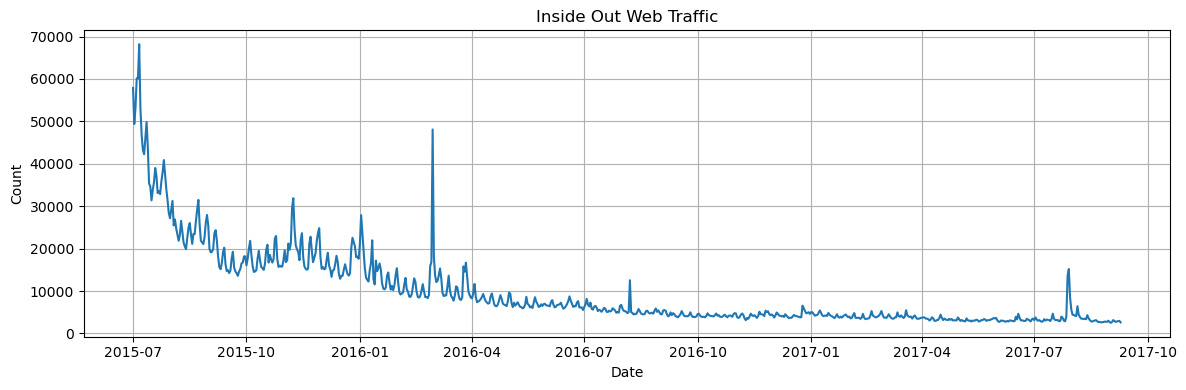

In [9]:
fig, ax = plt.subplots(figsize = (12,4))

plt.plot(df)
plt.title('Inside Out Web Traffic')
plt.ylabel('Count')
plt.xlabel('Date')
plt.grid()
# plt.ylim((0,4000))

plt.tight_layout()
plt.show()

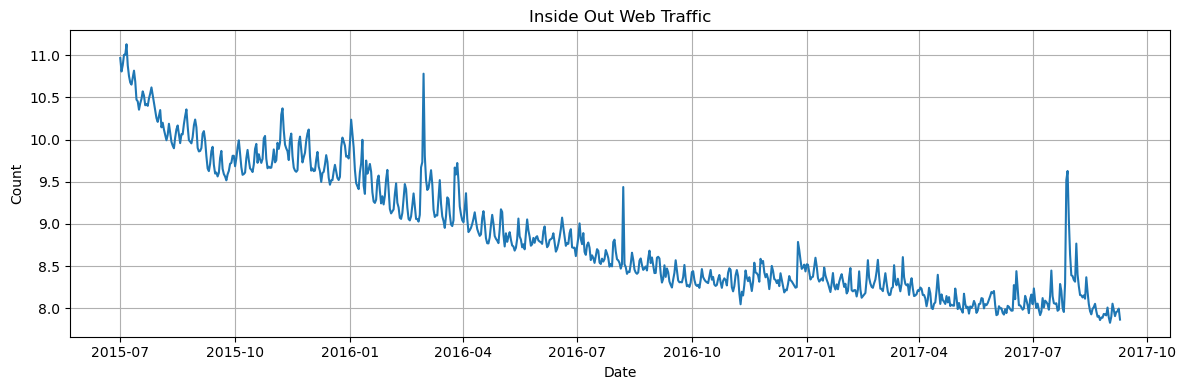

In [10]:
fig, ax = plt.subplots(figsize = (12,4))

plt.plot(np.log(df))
plt.title('Inside Out Web Traffic')
plt.ylabel('Count')
plt.xlabel('Date')
plt.grid()
# plt.ylim((0,4000))

plt.tight_layout()
plt.show()

### 1 Month

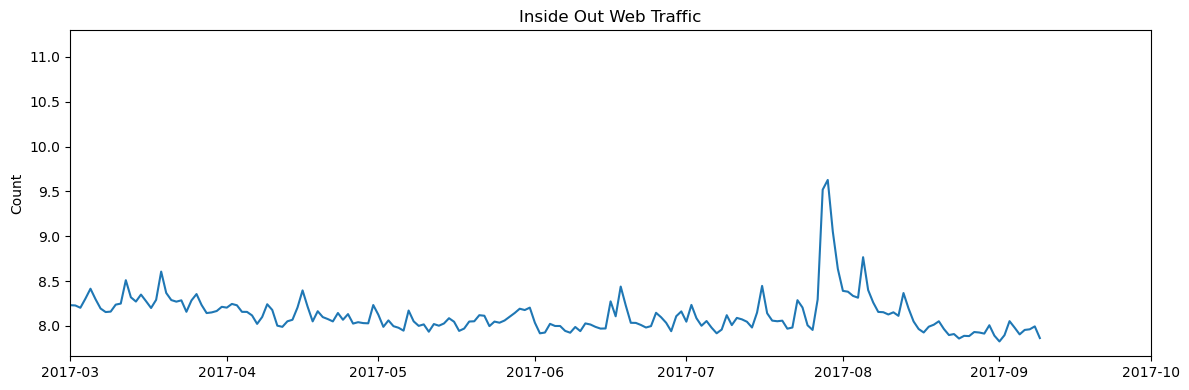

In [11]:
fig, ax = plt.subplots(figsize = (12,4))

plt.plot(np.log(df))
plt.title('Inside Out Web Traffic')
plt.ylabel('Count')
plt.xlim(datetime.datetime(2017, 3, 1), datetime.datetime(2017, 10, 1))
plt.tight_layout()
plt.show()

In [12]:
df_train_log = np.log(df_train)
df_test_log = np.log(df_test)

### Inside Out Web Traffic Analysis

##### 1 Day

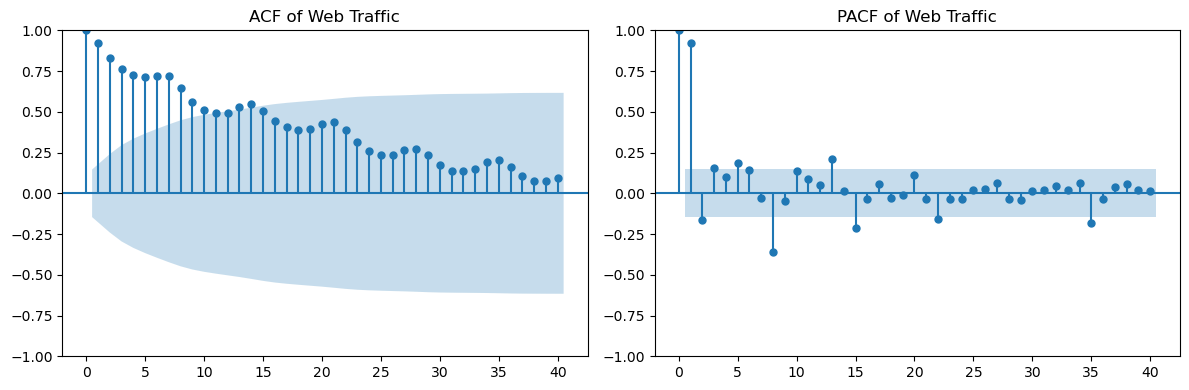

In [13]:
fig, (ax1,ax2) = plt.subplots(1 , 2, figsize=(12, 4))
plot_acf(df_train_log['Web_Traffic'], lags = 40, ax = ax1, title = 'ACF of Web Traffic')
plot_pacf(df_train_log['Web_Traffic'], lags = 40, ax = ax2, title = 'PACF of Web Traffic')

plt.tight_layout()
plt.show()

In [14]:
max_ar=list(range(0,2+1))
max_ma=list(range(0,2+1))
max_sar = list(range(0,1+1))
max_sma = list(range(0,1+1))
shape = (len(max_ar), len(max_ma), len(max_sar), len(max_sma))

aic_matrix = np.full(shape, np.inf)
aicc_matrix = np.full(shape, np.inf)
bic_matrix = np.full(shape, np.inf)

total = shape[0] * shape[1] * shape[2] * shape[3]
progress = tqdm(total=total, desc="ARIMA Grid Search")

for p in max_ar:
    for q in max_ma:
        for P in max_sar:
            for Q in max_sma:
                try:
                    with warnings.catch_warnings():
                        warnings.simplefilter("ignore")
                        fit_result = SARIMAX(
                            df_train_log['Web_Traffic'],
                            order=(p, 1, q),
                            seasonal_order = (P,0,Q,7),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

                    k = len(fit_result.params)
                    n = len(df_train_log['Web_Traffic'])
                    aicc = fit_result.aic + (2 * k**2 + 2 * k) / (n - k - 1)

                    aic_matrix[p, q, P, Q] = fit_result.aic
                    aicc_matrix[p, q, P, Q] = aicc
                    bic_matrix[p, q, P, Q] = fit_result.bic

                except Exception:

                    pass

                progress.update(1)

progress.close()
min_idx = np.unravel_index(np.argmin(aicc_matrix), aicc_matrix.shape)

p_best = min_idx[0]
q_best = min_idx[1]
P_best = min_idx[2]
Q_best = min_idx[3]
best_value = aicc_matrix[min_idx]

print(p_best,
Q_best ,
P_best,
Q_best,
best_value)

ARIMA Grid Search: 100%|██████████| 36/36 [00:07<00:00,  5.11it/s]

0 1 1 1 -387.03651594045334


In [15]:
sarima_model = SARIMAX(
                            df_train_log['Web_Traffic'],
                            order=(0, 1, 1),
                            seasonal_order = (1,0,1,7),
                            enforce_stationarity = True,
                            enforce_invertibility = True
                        ).fit()

df_train_log['SARIMA_resid'] = sarima_model.resid

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


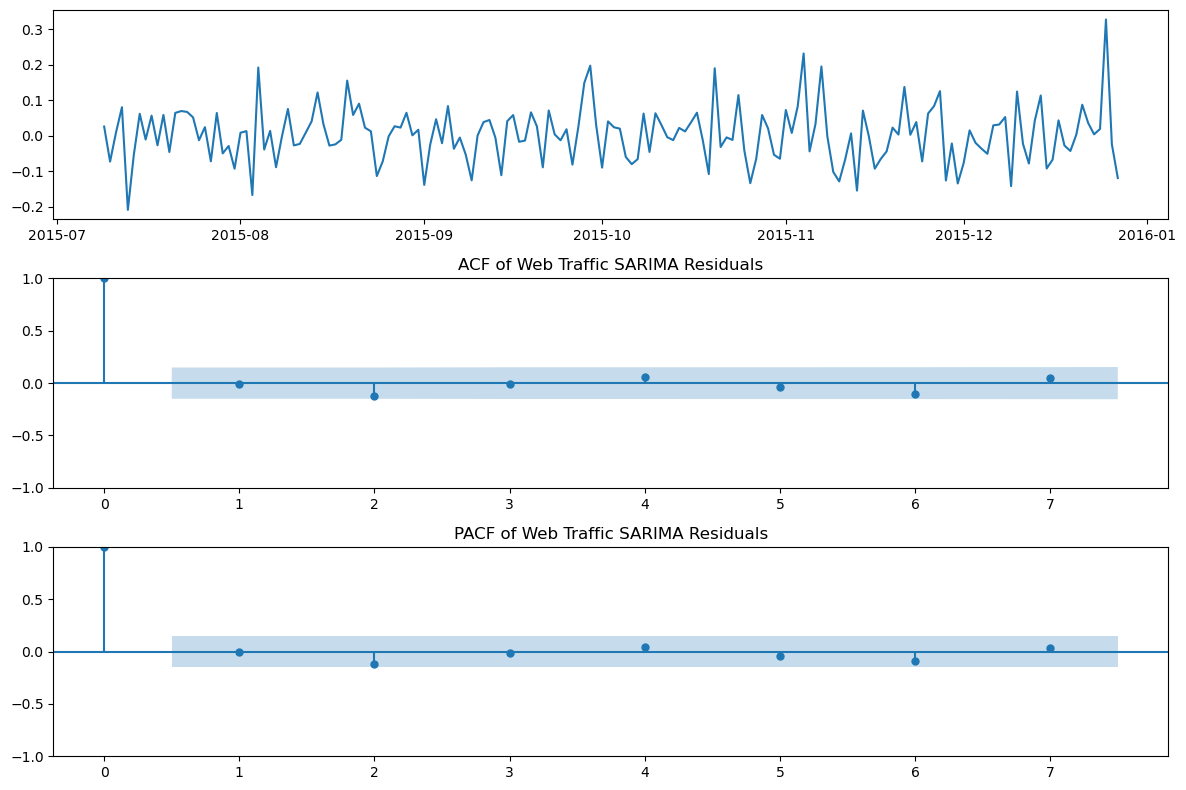

In [16]:
fig, (ax1,ax2,ax3) = plt.subplots(3 , 1,  figsize=(12, 8))
ax1.plot(df_train_log['SARIMA_resid'].iloc[8:])
plot_acf(df_train_log['SARIMA_resid'].iloc[8:], lags = 7, ax = ax2, title = 'ACF of Web Traffic SARIMA Residuals')
plot_pacf(df_train_log['SARIMA_resid'].iloc[8:], lags = 7, ax = ax3, title = 'PACF of Web Traffic SARIMA Residuals')
plt.tight_layout()
plt.show()

In [17]:
boxTest = acorr_ljungbox(df_train_log['SARIMA_resid'], lags=[7])
print(f"Ljung-Box: Test statistic = {boxTest.iloc[0]['lb_stat']:.4f}; p-value = {boxTest.iloc[0]['lb_pvalue']:.4f}")

adfTest = adfuller(df_train_log['SARIMA_resid'], autolag='AIC')
print(f"ADF: Test statistic = {adfTest[0]:.4f}; p-value = {adfTest[1]:.4f}")

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    kpssTest = kpss(df_train_log['SARIMA_resid'], regression='c', nlags='auto')
print(f"KPSS: Test statistic = {kpssTest[0]:.4f}; p-value = {kpssTest[1]:.4f}")

Ljung-Box: Test statistic = 0.2172; p-value = 1.0000
ADF: Test statistic = -136.6863; p-value = 0.0000
KPSS: Test statistic = 0.3148; p-value = 0.1000


In [18]:
test = sarima_model.get_forecast(steps=len(df_test_log['Web_Traffic'])).conf_int()

In [19]:
test.head()

,lower Web_Traffic,upper Web_Traffic
2015-12-28,9.677662,9.985502
2015-12-29,9.509815,9.947898
2015-12-30,9.432460,9.970109
2015-12-31,9.412392,10.033856
2016-01-01,9.467607,10.162854


In [20]:
pred_sarima_web_traffic_forecasts = sarima_model.get_forecast(steps=len(df_test_log['Web_Traffic']))
pred_sarima_web_traffic_confint = pred_sarima_web_traffic_forecasts.conf_int()
pred_sarima_web_traffic = pred_sarima_web_traffic_forecasts.predicted_mean

df_test_log['Web_Traffic'] = np.exp(df_test_log['Web_Traffic'])
df_test_log['Web_Traffic_SARIMA_pred'] = np.exp(pred_sarima_web_traffic)
df_test_log['Web_Traffic_SARIMA_lower_confint'] = np.exp(pred_sarima_web_traffic_confint['lower Web_Traffic'])
df_test_log['Web_Traffic_SARIMA_upper_confint'] = np.exp(pred_sarima_web_traffic_confint['upper Web_Traffic'])

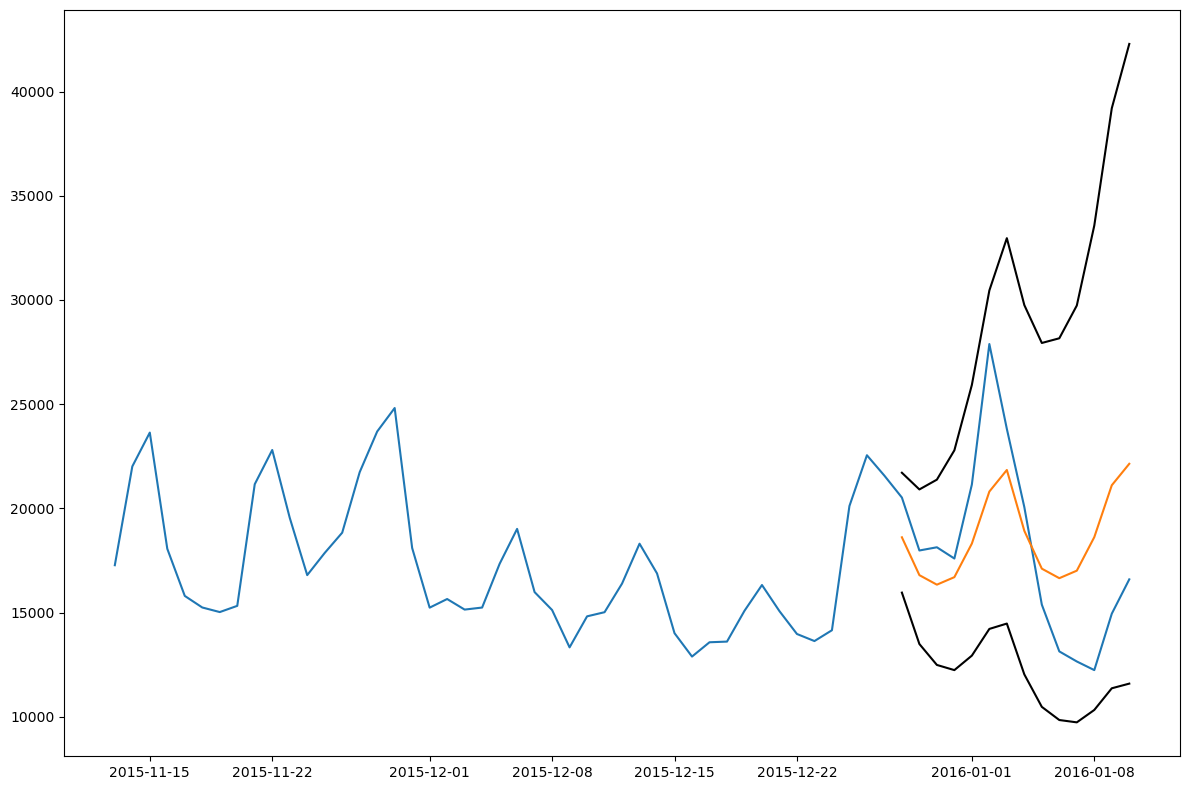

In [65]:
plt.figure(1,(12,8))
plt.plot(df.iloc[(len(df_train_log)-45):(len(df_train_log)+len(df_test_log))])
plt.plot(df_test_log['Web_Traffic_SARIMA_pred'])
plt.plot(df_test_log['Web_Traffic_SARIMA_lower_confint'], color = 'black')
plt.plot(df_test_log['Web_Traffic_SARIMA_upper_confint'], color = 'black')
plt.tight_layout()
plt.show()

In [22]:
df_test_log.head()

,Web_Traffic,Web_Traffic_SARIMA_pred,Web_Traffic_SARIMA_lower_confint,Web_Traffic_SARIMA_upper_confint
2015-12-28,20519.0,18612.368713,15957.139065,21709.422203
2015-12-29,17979.0,16795.335059,13491.502394,20908.218485
2015-12-30,18133.0,16338.576460,12487.203060,21377.812104
2015-12-31,17593.0,16699.328319,12239.110600,22784.953532
2016-01-01,21143.0,18310.507540,12933.900329,25922.164069


In [23]:
df_test_log['Web_Traffic_SARIMA_resid'] = df_test_log['Web_Traffic_SARIMA_pred'] - df_test_log['Web_Traffic']
final_sarima_pred_pm = np.sum(df_test_log['Web_Traffic_SARIMA_resid']**2)/np.sum((df_test_log['Web_Traffic']-np.mean(df_test_log['Web_Traffic']))**2)
print(final_sarima_pred_pm)

0.8449728632517138


In [24]:
def evaluate_performance(true, pred, model_name="Model"):
    mspe = mean_squared_error(true, pred)
    mae = mean_absolute_error(true, pred)
    mape = np.mean(np.abs((true - pred) / (true + 1e-6)))
    pm = (np.sum((true - pred) ** 2) / np.sum((true - np.mean(true)) ** 2))

    print(f"=== {model_name} Performance ===")
    print(f"MSPE: {mspe:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"MAPE: {mape:.4f}")
    print(f"PM:   {pm:.4f}")
    print("-" * 40)

In [34]:
df_lstm = pd.DataFrame({'y':df}).copy()
df_lstm.reset_index(inplace=True)
df_lstm.rename(columns={'index':'ds'},inplace=True)
df_lstm['unique_id'] = 'ts1'
df_lstm = df_lstm[['ds','y','unique_id']]

df_train_lstm = df_lstm.iloc[:train_end_range]
df_test_lstm = df_lstm.iloc[train_end_range:(train_end_range+test_end_range)]


In [54]:
horizon = 14
input_sizes = [-1, 2, 3, 5, 10, 30, 45]

for input_size in input_sizes:
    print(f"\nTraining LSTM with input_size = {input_size}")

    # Model setup
    lstm_model = LSTM(
        h=horizon,
        input_size=input_size,
        loss=DistributionLoss(distribution='Normal', level=[90, 95]),
        scaler_type='robust',
        encoder_n_layers=1,
        encoder_hidden_size=4,
        decoder_hidden_size=4,
        decoder_layers=1,
        enable_progress_bar=False,
        enable_model_summary=False,
        max_steps=200,
    )

    nf = NeuralForecast(models=[lstm_model], freq='D')
    nf.fit(df=df_train_lstm)

    # Forecast and merge
    forecasts = nf.predict()
    merged = forecasts.merge(df_test_lstm, on='ds', how='inner')

    # Extract true and predicted
    y_true = merged['y'].values
    y_pred = merged['LSTM'].values

    evaluate_performance(y_true, y_pred, model_name=f"LSTM (input_size={input_size})")

C:\Users\conno\miniconda3\envs\isye6414\Lib\site-packages\neuralforecast\common\_base_model.py:152: UserWarning: Input size too small. Automatically setting input size to 3 * horizon = 42
  warnings.warn(
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training LSTM with input_size = -1


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (input_size=-1) Performance ===
MSPE: 27460273.4729
MAE:  4009.4295
MAPE: 0.2009
PM:   1.5031
----------------------------------------

Training LSTM with input_size = 2


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

=== LSTM (input_size=10) Performance ===
MSPE: 26785820.7357
MAE:  3971.1267
MAPE: 0.2002
PM:   1.4662
----------------------------------------

Training LSTM with input_size = 30


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (input_size=30) Performance ===
MSPE: 28926775.1234
MAE:  4125.7781
MAPE: 0.2053
PM:   1.5834
----------------------------------------

Training LSTM with input_size = 45


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (input_size=45) Performance ===
MSPE: 25828712.9236
MAE:  3878.0854
MAPE: 0.1963
PM:   1.4138
----------------------------------------


In [56]:
horizon = 14
scaler_types = ['identity', 'standard', 'robust']

for scaler in scaler_types:
    print(f"\nTraining LSTM with scaler_type = '{scaler}'")

    # Model setup
    lstm_model = LSTM(
        h=horizon,
        input_size=5,
        loss=DistributionLoss(distribution='Normal', level=[90, 95]),
        scaler_type=scaler,
        encoder_n_layers=1,
        encoder_hidden_size=4,
        decoder_hidden_size=4,
        decoder_layers=1,
        max_steps=200,
        enable_progress_bar=False,
        enable_model_summary=False,
        # trainer=trainer
    )

    nf = NeuralForecast(models=[lstm_model], freq='D')
    nf.fit(df=df_train_lstm)

    # Forecast and merge
    forecasts = nf.predict()
    merged = forecasts.merge(df_test_lstm, on='ds', how='inner')

    # Extract true and predicted
    y_true = merged['y'].values
    y_pred = merged['LSTM'].values

    # Evaluate
    evaluate_performance(y_true, y_pred, model_name=f"LSTM (scaler_type='{scaler}')")

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training LSTM with scaler_type = 'identity'


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (scaler_type='identity') Performance ===
MSPE: 342427450.6579
MAE:  18004.4226
MAPE: 1.0000
PM:   18.7434
----------------------------------------

Training LSTM with scaler_type = 'standard'


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (scaler_type='standard') Performance ===
MSPE: 18919128.0681
MAE:  3443.3182
MAPE: 0.1917
PM:   1.0356
----------------------------------------

Training LSTM with scaler_type = 'robust'


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (scaler_type='robust') Performance ===
MSPE: 22676921.4948
MAE:  3975.7259
MAPE: 0.2525
PM:   1.2413
----------------------------------------


In [57]:
horizon = 14
input_size = 5
scaler_type = 'standard'

structure_combinations = [
    (1, 2),
    (1, 4),
    (1, 8),   # baseline
    (1, 16),
    (2, 2),
    (2, 4)
]

for n_layers, hidden_size in structure_combinations:
    print(f"\nTraining LSTM with encoder_n_layers = {n_layers}, encoder_hidden_size = {hidden_size}")

    # Model setup
    lstm_model = LSTM(
        h=horizon,
        input_size=input_size,
        loss=DistributionLoss(distribution='Normal', level=[90, 95]),
        scaler_type=scaler_type,
        encoder_n_layers=n_layers,
        encoder_hidden_size=hidden_size,
        decoder_hidden_size=hidden_size,
        decoder_layers=1,
        max_steps=200,
        enable_progress_bar=False,
        enable_model_summary=False
    )

    nf = NeuralForecast(models=[lstm_model], freq='D')
    nf.fit(df=df_train_lstm)

    # Forecast and merge
    forecasts = nf.predict()
    merged = forecasts.merge(df_test_lstm, on='ds', how='inner')

    # Extract true and predicted
    y_true = merged['y'].values
    y_pred = merged['LSTM'].values

    # Evaluate
    evaluate_performance(y_true, y_pred, model_name=f"LSTM (layers={n_layers}, hidden={hidden_size})")

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



Training LSTM with encoder_n_layers = 1, encoder_hidden_size = 2


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (layers=1, hidden=2) Performance ===
MSPE: 17255029.1747
MAE:  3492.1636
MAPE: 0.2021
PM:   0.9445
----------------------------------------

Training LSTM with encoder_n_layers = 1, encoder_hidden_size = 4


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


...

=== LSTM (layers=1, hidden=16) Performance ===
MSPE: 19547593.8741
MAE:  3533.9044
MAPE: 0.1969
PM:   1.0700
----------------------------------------

Training LSTM with encoder_n_layers = 2, encoder_hidden_size = 2


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (layers=2, hidden=2) Performance ===
MSPE: 20034873.0839
MAE:  3625.1092
MAPE: 0.1997
PM:   1.0966
----------------------------------------

Training LSTM with encoder_n_layers = 2, encoder_hidden_size = 4


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM (layers=2, hidden=4) Performance ===
MSPE: 19262358.9779
MAE:  3465.7753
MAPE: 0.1941
PM:   1.0544
----------------------------------------


In [60]:
loss_candidates = [
    ("Normal", DistributionLoss(distribution='Normal', level=[90, 95])),
    ("MAE", MAE()),
    ("MSE", MSE()),
    ("SMAPE", SMAPE()),
]

results = []

for loss_name, loss_obj in loss_candidates:
    alias = f"LSTM_{loss_name}"
    print(f"\n=== Training {alias} ===")
    lstm_model = LSTM(
        h=14,
        input_size=5,
        loss=loss_obj,
        scaler_type='standard',
        encoder_hidden_size=2,
        decoder_hidden_size=2,
        encoder_n_layers=1,
        decoder_layers=1,
        max_steps=200,
        alias=alias,
        enable_progress_bar=False,
        enable_model_summary=False
    )

    # Fit & Predict
    nf = NeuralForecast(models=[lstm_model], freq='D')
    nf.fit(df=df_train_lstm)

    forecasts = nf.predict()

    merged = forecasts.merge(df_test_lstm[['unique_id', 'ds', 'y']], on=['unique_id', 'ds'], how='inner')


    y_true = merged['y'].values
    y_pred = merged[alias].values


    evaluate_performance(y_true, y_pred, model_name=f"{alias}")


Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.



=== Training LSTM_Normal ===


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM_Normal Performance ===
MSPE: 17255029.1747
MAE:  3492.1636
MAPE: 0.2021
PM:   0.9445
----------------------------------------

=== Training LSTM_MAE ===


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM_MAE Performance ===
MSPE: 21338339.8382
MAE:  3422.3099
MAPE: 0.1859
PM:   1.1680
----------------------------------------

=== Training LSTM_MSE ===


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM_MSE Performance ===
MSPE: 17092965.5002
MAE:  3106.5963
MAPE: 0.1780
PM:   0.9356
----------------------------------------

=== Training LSTM_SMAPE ===


`Trainer.fit` stopped: `max_steps=200` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


=== LSTM_SMAPE Performance ===
MSPE: 29741775.2199
MAE:  4682.9075
MAPE: 0.2997
PM:   1.6280
----------------------------------------


In [61]:

horizon = 14
lstm_model = LSTM(
    h=horizon,
    input_size=5,
    #context_size=30,
    loss=MSE(),
    #loss=MAE(),
    scaler_type='standard',
    encoder_n_layers=1,
    encoder_hidden_size=2,
    decoder_hidden_size=2,
    decoder_layers=1,
    max_steps=200,
    enable_progress_bar=False,
    enable_model_summary=False
)

nf = NeuralForecast(models=[lstm_model],freq='D')
nf.fit(df=df_train_lstm)

Seed set to 1
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
`Trainer.fit` stopped: `max_steps=200` reached.


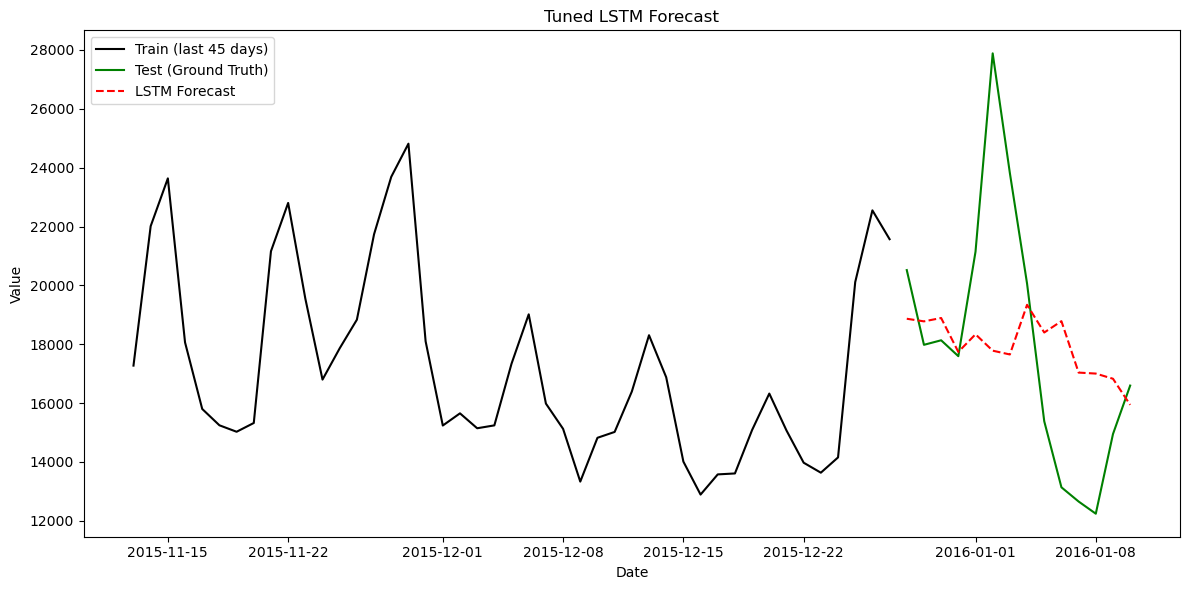

In [67]:
# Predict
forecasts = nf.predict()
# Merge forecast with test set for comparison
merged = forecasts.merge(df_test_lstm, on='ds', how='inner')
plt.figure(figsize=(12, 6))


# Get the start date of the test set
test_start_date = df_test_lstm['ds'].min()
# Select last 45 days from train_data before test starts
train_subset = df_train_lstm[df_train_lstm['ds'] >= test_start_date - pd.Timedelta(days=45)]
# Plot training data
plt.plot(train_subset['ds'], train_subset['y'], label='Train (last 45 days)', color='black')

# Plot test data (ground truth)
plt.plot(merged['ds'], merged['y'], label='Test (Ground Truth)', color='green')

# Plot forecast mean (LSTM prediction)
if 'LSTM' in merged.columns:
    plt.plot(merged['ds'], merged['LSTM'], label='LSTM Forecast', color='red', linestyle='--')
# Plot 90% confidence interval
if 'LSTM-lo-90' in merged.columns and 'LSTM-hi-90' in merged.columns:
    plt.fill_between(merged['ds'], merged['LSTM-lo-90'], merged['LSTM-hi-90'],
                     alpha=0.15, color='blue', label='90% Confidence Interval')

# Plot 95% confidence interval
if 'LSTM-lo-95' in merged.columns and 'LSTM-hi-95' in merged.columns:
    plt.fill_between(merged['ds'], merged['LSTM-lo-95'], merged['LSTM-hi-95'],
                     alpha=0.3, color='orange', label='95% Confidence Interval')

# Final plot adjustments
plt.title('Tuned LSTM Forecast')
plt.xlabel('Date')
plt.ylabel('Value')
plt.legend()

plt.tight_layout()
plt.show()